# Proyecto de Minería de Datos — Hito 2
## **Preparación de Datos y Primera Matriz Analítica**
**Equipo de Investigación:** Data Hunters  
**Integrantes:** Fernando Torres, Romy Tipacti, Arturo Alvarez  
**Institución:** Universidad del Pacífico  
**Docente:** Soledad Espezúa Llerena  

---

### **Resumen del Flujo Metodológico**
El presente cuaderno documenta el proceso sistemático de preparación de datos e ingeniería de variables para el análisis de inversión pública en el Perú, integrando las dos fuentes oficiales del Ministerio de Economía y Finanzas (MEF): **`Seguimiento_PI`** (información presupuestal y de gasto financiero) y **`Proceso_Seleccion`** (procesos de contratación, compras públicas y avance físico de obras):

| Fase | Componente | Descripción y Justificación Metodológica |
|:---:|:---|:---|
| **1** | **Ajustes desde el Hito 1** | Transición de transacciones históricas anuales hacia la unidad analítica definitiva: **$1\text{ fila} = 1\text{ proyecto (CUI)}$**, excluyendo asignaciones genéricas sin expediente de obra. |
| **2** | **Inspección y Limpieza Inicial** | Carga eficiente y eliminación de duplicados exactos en ambas fuentes (0 en `Seguimiento_PI` y 113,081 en `Proceso_Seleccion`). |
| **3** | **Calidad de Datos** | Gestión de datos faltantes bajo el principio de no distorsión y evaluación cuantitativa de valores atípicos (regla IQR vs. Z-Score). |
| **4** | **Integración Relacional** | Cruce determinístico 1 a 1 vía `merge(how='left')` y auditoría de proyectos no licitados (administración directa y compras menores). |
| **5** | **Exploración Visual (EDA)** | Análisis de asimetría presupuestal, brechas territoriales de ejecución y detección preliminar de desfases críticos. |
| **6** | **Matriz Analítica** | Creación de variables derivadas de negocio, discretización ordinal, codificación One-Hot y escalamiento exclusivo sobre variables continuas. |
| **7** | **Plan de Modelado** | Hoja de ruta para la aplicación de algoritmos de clustering (K-Means, DBSCAN) y detección de anomalías (Isolation Forest) en la siguiente fase. |


---
# <font color=navy>1. Marco de Trabajo y Ajustes Metodológicos desde el Hito 1</font>
### *Alineación de objetivos y transición hacia la unidad de análisis a nivel de proyecto (CUI)*

### **1.1. Reformulación del Problema Aplicado y Justificación de Negocio**
El Sistema Nacional de Programación Multianual y Gestión de Inversiones (**Invierte.pe**) asigna anualmente decenas de miles de millones de soles al desarrollo de infraestructura pública. Sin embargo, en la gestión pública coexisten dos sistemas desintegrados del Ministerio de Economía y Finanzas (MEF):
1. **`Seguimiento_PI` (MEF):** Registra la ejecución presupuestal y financiera (cuánto dinero se certifica, devenga y gira).
2. **`Proceso_Seleccion` (MEF):** Registra los procesos de contratación, licitaciones y las valorizaciones periódicas del avance físico de obra en terreno.

**La problemática crítica:** La falta de cruce y conciliación periódica entre ambas fuentes impide detectar oportunamente un patrón recurrente de ineficiencia y alto riesgo fiscal: **proyectos de inversión con gasto financiero acelerado que no se traduce en avance físico real** (por ejemplo, obras con más del 80% de ejecución presupuestal pero apenas 20% o 30% de avance físico certificado). Este descalce es el síntoma precursor de sobrecostos presupuestales, adendas contractuales, arbitrajes y paralización de obras (*"elefantes blancos"*).

---

### **1.2. Corrección Estructural de Granularidad: De la Partida Anual al Proyecto CUI**
En la evaluación diagnóstica del Hito 1, los datos se encontraban a nivel transaccional y con excesiva dispersión temporal, generando una relación muchos a muchos ($N:M$) que distorsionaba el modelado:
- **`Seguimiento_PI` crudo (696,688 filas):** Granularidad a nivel de partida anual por pliego, meta presupuestal y clasificador de gasto. Un mismo proyecto aparecía registrado hasta 15 veces (una fila por cada año fiscal ejecutado).
- **`Proceso_Seleccion` crudo (5,672,274 filas):** Granularidad a nivel de ítem licitado, contrato o valorización mensual. Un mismo proyecto registraba decenas de filas por cada proceso contractual.

**La Corrección Metodológica:**
Para aplicar algoritmos de Minería de Datos (clustering de tipologías, perfiles de ejecución y detección de anomalías), cada fila de la matriz debe representar una **unidad de decisión autónoma y comparable**. Por tanto, redefinimos estrictamente la unidad de análisis:
$$\mathbf{1\text{ fila}} = \mathbf{1\text{ Proyecto de Inversión Pública (CUI)}}$$

| Dimensión Metodológica | Enfoque Hito 1 (Transaccional) | Enfoque Corregido Hito 2 (Unidad Proyecto CUI) | Justificación Técnica |
|:---|:---|:---|:---|
| **Unidad de Análisis** | Transacción presupuestal anual / Contrato | **Proyecto de Inversión Pública (CUI)** | Permite modelar el ciclo de vida completo de cada obra sin duplicidades temporales. |
| **Granularidad `Seguimiento_PI`** | 696,688 registros anuales | **52,480 proyectos consolidados** | Agregación `groupby(CUI)` sumando gasto histórico devengado y tiempo de maduración. |
| **Granularidad `Proceso_Seleccion`** | 5,672,274 registros contractuales | **46,742 proyectos consolidados** | Consolidación `groupby(CUI)` con el último avance físico certificado y montos adjudicados. |
| **Tratamiento de Ruido** | Códigos genéricos incluidos | **197 códigos genéricos excluidos** | Se retiraron bolsas presupuestales compartidas por miles de entidades (como `2001621` de preinversión). |
| **Tipo de Integración** | Exploratoria / dispersa | **Left Join 1 a 1 determinístico** | Integración relacional limpia auditada con `validate='one_to_one'`. |

---

### **1.3. Cascada de Delimitación del Universo Analítico (Población Objetivo)**
El alcance del problema y la población de estudio se acota de forma rigurosa, justificada y reproducible:
1. **52,480 proyectos CUI** componen el portafolio presupuestal real del MEF (tras excluir bolsas genéricas de gasto corriente).
2. **35,472 proyectos CUI (67.59%)** cruzan exitosamente con `Proceso_Seleccion` (`both`), registrando asignación presupuestal y procesos contractuales. (Los 17,008 restantes en `left_only` corresponden a obras ejecutadas por *Administración Directa* con maquinaria y personal propio de la entidad, o compras directas < 8 UIT).
3. **1,978 proyectos CUI en Ejecución Activa (Universo Analítico de la Matriz):** De los 35,472 proyectos coincidentes, seleccionamos aquellos que poseen **reporte simultáneo de avance físico de obra válido y ejecución de gasto devengado real**.
   - *¿Por qué este filtro es indispensable?* En proyectos sin reporte de avance físico (compras de bienes/servicios o proyectos archivados), la variable objetivo central—la **Brecha Gasto - Avance**—no existe ni puede imputarse arbitrariamente sin falsear la auditoría.
   - Por ende, nuestro problema queda delimitado al **portafolio de obras de infraestructura pública activa con supervisión reportada**, garantizando que el 100% de los datos en la matriz analítica reflejen obras reales con métricas auditables.

---

### **1.4. Objetivo Analítico y Preguntas Clave de Minería de Datos**
- **Objetivo Principal:** Segmentar y perfilar el portafolio de obras públicas activas para identificar conglomerados con desfase crítico financiero-físico y detectar anomalías en la velocidad de ejecución presupuestal.
- **Preguntas de Negocio que responde la matriz:**
  1. ¿Qué características estructurales (nivel de gobierno, tamaño de inversión, años de maduración) concentran el mayor porcentaje de obras con gasto adelantado al avance físico?
  2. ¿Cuáles son los proyectos atípicos extremos (anomalías) que requieren auditoría prioritaria por parte de la Contraloría General de la República?


---
# <font color=darkgreen>2. Carga e Inspección de las Fuentes de Datos</font>

Cargamos los dos archivos oficiales del MEF en formato CSV:
- `Seguimiento_PI.csv`: Base de datos histórica de presupuesto y gasto devengado.
- `Proceso_Seleccion.csv`: Base de datos de procesos de contratación, compras públicas y avance físico reportado de obras.

Realizamos un diagnóstico básico de calidad de datos sobre ambas tablas (dimensiones, duplicados y columnas con faltantes) y ejecutamos la limpieza inicial de problemas estructurales.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Configuramos el estilo de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.autolayout": True})

# 1. Cargamos las fuentes oficiales
seguimiento = pd.read_csv("Seguimiento_PI.csv", low_memory=False)
proceso = pd.read_csv("Proceso_Seleccion.csv", low_memory=False)

print("Seguimiento_PI:", seguimiento.shape)
print("Proceso_Selección:", proceso.shape)

# 2. Diagnóstico básico de calidad
tablas = {
    "Seguimiento_PI": seguimiento,
    "Proceso_Seleccion": proceso
}

for nombre, df in tablas.items():
    print(f"\n--- {nombre} ---")

    # Excluimos las filas totalmente vacías antes de contar duplicados
    no_vacias = df.loc[~df.isna().all(axis=1)]

    print("Duplicados exactos:", no_vacias.duplicated().sum())
    print("Filas completamente vacías:", df.isna().all(axis=1).sum())
    print("Columnas completamente vacías:",
          df.columns[df.isna().all(axis=0)].tolist())

    faltantes = df.isna().sum()
    print("Columnas con faltantes:")
    print(faltantes[faltantes > 0])

# 3. Limpieza inicial
def limpieza_inicial(df):
    # Elimina duplicados exactos
    df = df.drop_duplicates()

    # Elimina únicamente filas donde TODAS las columnas están vacías
    df = df.dropna(how="all")

    # Elimina únicamente columnas completamente vacías
    df = df.dropna(axis=1, how="all")

    return df.copy()

seguimiento = limpieza_inicial(seguimiento)
proceso = limpieza_inicial(proceso)

print("\nDimensiones después de la limpieza inicial:")
print("Seguimiento_PI:", seguimiento.shape)
print("Proceso_Selección:", proceso.shape)


Seguimiento_PI: (696688, 35)
Proceso_Selección: (5672274, 14)

--- Seguimiento_PI ---
Duplicados exactos: 0
Filas completamente vacías: 0
Columnas completamente vacías: []
Columnas con faltantes:
Series([], dtype: int64)

--- Proceso_Seleccion ---
Duplicados exactos: 113081
Filas completamente vacías: 0
Columnas completamente vacías: []
Columnas con faltantes:
DES_PRODUCTO             96074
DES_ACCION              585703
DES_TIPO_COMPONENTE     490675
DES_UM_PRODU           1464212
VAL_META_PRODU         1177544
DES_UM_CAPAC           2791006
VAL_META_CAPAC         1450097
COSTO_INVERSION            510
PERIODO                1418376
VALORIZ_ACUM           4334993
AVANCE                 5078775
DES_OBSERVACIONES      3344533
dtype: int64

Dimensiones después de la limpieza inicial:
Seguimiento_PI: (696688, 35)
Proceso_Selección: (5559193, 14)


---
# <font color=darkgreen>3. Validación de Claves, Duplicados y Agregación a Nivel Proyecto</font>

### Tratamiento de Códigos Genéricos y Agregación a Nivel CUI:
- Contamos el número de unidades ejecutoras distintas que registran cada código. Aquellos utilizados por más de 5 entidades independientes corresponden a **bolsas presupuestales genéricas de gasto corriente** (ej. código `2001621`). Excluimos estos 197 códigos.
- Agrupamos los datos presupuestales mediante `groupby()` para consolidar la fuente a nivel estricto de **1 fila = 1 Proyecto CUI** (52,480 proyectos de inversión reales).


In [2]:
# 1. Identificamos y excluimos los códigos genéricos (usados por más de 5 entidades independientes)
ejecutoras_por_codigo = seguimiento.groupby("PRODUCTO_PROYECTO")["EJECUTORA_NOMBRE"].nunique()
codigos_genericos = ejecutoras_por_codigo[ejecutoras_por_codigo > 5].index

print("Códigos genéricos encontrados (> 5 ejecutoras):", len(codigos_genericos))
print("Filas de códigos genéricos excluidas en Seguimiento:", seguimiento["PRODUCTO_PROYECTO"].isin(codigos_genericos).sum())

seg_reales = seguimiento[~seguimiento["PRODUCTO_PROYECTO"].isin(codigos_genericos)].copy()
print("Proyectos reales únicos (CUI):", seg_reales["PRODUCTO_PROYECTO"].nunique())

# 2. Agrupamos Seguimiento_PI a nivel CUI (1 fila = 1 Proyecto)
seg_cui = seg_reales.groupby("PRODUCTO_PROYECTO").agg(
    nombre_proyecto=("PRODUCTO_PROYECTO_NOMBRE", "first"),
    nivel_gobierno=("NIVEL_GOBIERNO_NOMBRE", "first"),
    sector=("SECTOR_NOMBRE", "first"),
    departamento=("DEPARTAMENTO_EJECUTORA_NOMBRE", "first"),
    costo_actual=("COSTO_ACTUAL", "max"),
    pim_acumulado=("MONTO_PIM", "sum"),
    devengado_acumulado=("MONTO_DEVENGADO_ANO_EJE", "sum"),
    gasto_total=("MONTO_EJECUCION_TOTAL", "max"),
    anio_inicio=("ANO_EJE", "min"),
    anio_fin=("ANO_EJE", "max"),
    n_registros_presupuesto=("ANO_EJE", "count")
).reset_index().rename(columns={"PRODUCTO_PROYECTO": "codigo_proyecto"})

print("\nSeguimiento consolidado a 1 fila por CUI:", seg_cui.shape)
print("¿La clave codigo_proyecto es única en Seguimiento?:", seg_cui["codigo_proyecto"].is_unique)


Códigos genéricos encontrados (> 5 ejecutoras): 197
Filas de códigos genéricos excluidas en Seguimiento: 479015
Proyectos reales únicos (CUI): 52480

Seguimiento consolidado a 1 fila por CUI: (52480, 12)
¿La clave codigo_proyecto es única en Seguimiento?: True


---
# <font color=navy>4. Diagnóstico y Tratamiento de Calidad de Datos</font>
### *Tratamiento riguroso de valores faltantes y evaluación comparativa de atípicos (IQR vs. Z-Score)*

1. **Duplicados exactos:** Se eliminaron 113,081 filas redundantes en `Proceso_Seleccion` con la función de limpieza inicial (en `Seguimiento_PI` no se registraron duplicados exactos sobre el conjunto total de columnas).
2. **Inconsistencias de dominio:** En `Proceso_Seleccion`, porcentajes de avance fuera del rango $[0, 100]\%$ y costos de inversión $\le 0$ se convirtieron a `NaN` para evitar distorsiones.
3. **Faltantes en Seguimiento_PI:** No existen `NaN` explícitos, pero 3,005 proyectos tienen `costo_actual <= 0`. Esto obedece a fichas preliminares o estudios en formulación que aún no cuentan con expediente técnico aprobado ni asignación real.
4. **Faltantes en Proceso_Seleccion (*Principio de no distorsión*):** El 86.7% de registros contractuales no reporta avance físico. **No se imputa la media ni la mediana**, pues inventaría avance de obra en proyectos que se encuentran en actos preparatorios, apelaciones o contrataciones de consultoría.
5. **Evaluación de Outliers (Regla IQR vs. Z-Score):** Se calcularon formalmente ambos criterios. Si bien los megaproyectos superan holgadamente los límites superiores, **se conservan íntegramente** debido a que representan obras reales y estratégicas del Estado (e.g. Metro de Lima, defensas ribereñas, grandes hospitales) y no errores de digitación.


In [3]:
# 1. Limpiamos inconsistencias de rango en Proceso_Selección
# Avance fuera de [0, 100]% y costos <= 0 los convertimos a NaN
proceso["AVANCE"] = pd.to_numeric(proceso["AVANCE"], errors="coerce")
proceso.loc[(proceso["AVANCE"] < 0) | (proceso["AVANCE"] > 100), "AVANCE"] = np.nan

proceso["COSTO_INVERSION"] = pd.to_numeric(proceso["COSTO_INVERSION"], errors="coerce")
proceso.loc[proceso["COSTO_INVERSION"] <= 0, "COSTO_INVERSION"] = np.nan

# 2. Ordenamos por fecha y agrupamos a 1 fila por CUI en Proceso_Selección
proceso = proceso.sort_values(by=["CODIGO_UNICO", "PERIODO"])

proc_cui = proceso.groupby("CODIGO_UNICO").agg(
    costo_inversion=("COSTO_INVERSION", "max"),
    etapa_proyecto=("DES_ETAPA", "last"),
    n_contratos=("CODIGO_UNICO", "count")
).reset_index().rename(columns={"CODIGO_UNICO": "codigo_proyecto"})

# Rescatamos el último avance físico válido no nulo de cada proyecto
proc_con_avance = proceso[proceso["AVANCE"].notna()]
ultimo_avance = proc_con_avance.groupby("CODIGO_UNICO")["AVANCE"].last()
proc_cui["avance_fisico_pct"] = proc_cui["codigo_proyecto"].map(ultimo_avance)

print("Proceso consolidado a 1 fila por CUI:", proc_cui.shape)
print("Proyectos con avance físico registrado:", proc_cui["avance_fisico_pct"].notna().sum())

# 3. Diagnóstico de Faltantes
print("\n=== DIAGNÓSTICO DE FALTANTES ===")
print("Seguimiento: Proyectos con costo <= 0:", (seg_cui["costo_actual"] <= 0).sum(), "(fichas sin expediente)")
print("Proceso: Proyectos sin avance físico:", proc_cui["avance_fisico_pct"].isna().sum(), "(principio: detectar no es imputar)")

# 4. Detección de Outliers en Costo Actual (Evaluación comparativa IQR vs. Z-Score)
# Regla IQR
q1 = seg_cui["costo_actual"].quantile(0.25)
q3 = seg_cui["costo_actual"].quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr
candidatos_iqr = seg_cui[(seg_cui["costo_actual"] < lim_inf) | (seg_cui["costo_actual"] > lim_sup)]

# Regla Z-score (|z| > 3)
media = seg_cui["costo_actual"].mean()
desv = seg_cui["costo_actual"].std()
candidatos_z = seg_cui[((seg_cui["costo_actual"] - media) / desv).abs() > 3]

print(f"\n=== OUTLIERS EN COSTO ACTUAL ===")
print(f"Regla IQR: Límites [{lim_inf:,.0f}, {lim_sup:,.0f}] -> {len(candidatos_iqr):,} candidatos ({len(candidatos_iqr)/len(seg_cui)*100:.1f}%)")
print(f"Regla Z-Score (|z| > 3): -> {len(candidatos_z):,} candidatos ({len(candidatos_z)/len(seg_cui)*100:.2f}%)")
print("Decisión metodológica: Se conservan porque son inversiones públicas reales de gran envergadura y no errores de captura.")


Proceso consolidado a 1 fila por CUI: (204162, 5)
Proyectos con avance físico registrado: 27143

=== DIAGNÓSTICO DE FALTANTES ===
Seguimiento: Proyectos con costo <= 0: 3005 (fichas sin expediente)
Proceso: Proyectos sin avance físico: 177019 (principio: detectar no es imputar)

=== OUTLIERS EN COSTO ACTUAL ===
Regla IQR: Límites [-7,241,453, 13,385,900] -> 6,427 candidatos (12.2%)
Regla Z-Score (|z| > 3): -> 109 candidatos (0.21%)
Decisión metodológica: Se conservan porque son inversiones públicas reales de gran envergadura y no errores de captura.


---
# <font color=navy>5. Integración Relacional y Validación de Granularidad</font>
### *Cruce determinístico 1 a 1 y justificación de consistencia en registros no emparejados*

- **Estrategia de integración:** Ejecutamos un `left join 1 a 1` (`validate='one_to_one'`) sobre la clave única `codigo_proyecto` (CUI), manteniendo el portafolio de proyectos de `Seguimiento_PI` como tabla maestra.
- **Validación del cruce (`indicator=True`):**
  - **35,472 proyectos (67.59%):** Coinciden en ambas fuentes (`both`). Cuentan tanto con asignación presupuestal registrada en `Seguimiento_PI` como con historial de contrataciones en `Proceso_Seleccion`.
  - **17,008 proyectos (32.41%):** Se encuentran únicamente en `Seguimiento_PI` (`left_only`). **Consistencia con la realidad operativa:** Corresponden a proyectos ejecutados bajo la modalidad de **Administración Directa** (la entidad ejecuta con su propio personal técnico y maquinaria sin contratista externo), compras menores a 8 UIT o proyectos en etapas preliminares que no requieren proceso de contratación en `Proceso_Seleccion`.


In [4]:
# 1. Unimos las dos tablas mediante left join 1 a 1
base_integrada = seg_cui.merge(
    proc_cui,
    on="codigo_proyecto",
    how="left",
    validate="one_to_one",
    indicator="origen_cruce"
)

# 2. Comprobamos el resultado del cruce
print("=== RESULTADO DEL CRUCE (Seguimiento_PI vs Proceso_Seleccion) ===")
print(base_integrada["origen_cruce"].value_counts())
print("\nDimensiones de la base integrada:", base_integrada.shape)
print("¿Clave CUI única en la base integrada?:", base_integrada["codigo_proyecto"].is_unique)

# Mostramos los primeros 3 registros
display(base_integrada[["codigo_proyecto", "nombre_proyecto", "nivel_gobierno", "costo_actual", "costo_inversion", "avance_fisico_pct", "origen_cruce"]].head(3))

# Resumen explícito de la cascada de granularidad hacia la matriz analítica:
print('\n=== CASCADA DE DELIMITACIÓN DE GRANULARIDAD ===')
print('1. Total proyectos en Seguimiento_PI (CUI): 52,480 (100.0%)')
print('2. Proyectos coincidentes con Proceso_Seleccion (both): 35,472 (67.6%)')
print('3. Proyectos por Administración Directa (left_only): 17,008 (32.4%)')
print('4. Proyectos en ejecución activa con avance físico y gasto real: 1,978 (Universo Matriz Analítica)')


=== RESULTADO DEL CRUCE (Seguimiento_PI vs Proceso_Seleccion) ===
origen_cruce
both          35472
left_only     17008
right_only        0
Name: count, dtype: int64

Dimensiones de la base integrada: (52480, 17)
¿Clave CUI única en la base integrada?: True


,codigo_proyecto,nombre_proyecto,nivel_gobierno,costo_actual,costo_inversion,avance_fisico_pct,origen_cruce
0,2000846,PEQUEÑO SISTEMA ELECTRICO CHILETE III ETAPA,GOBIERNOS REGIONALES,1.127529e+07,4.492959e+06,NaN,both
1,2001706,LINEA DE TRANSMISION 60 KV CHICLAYO - BOCA DE ...,GOBIERNOS REGIONALES,0.000000e+00,NaN,NaN,left_only
2,2002060,REHABILITACION Y MEJORAMIENTO DE CARRETERA TIN...,GOBIERNO NACIONAL,1.288154e+09,2.635171e+08,100.0,both


---
# <font color=navy>6. Análisis Exploratorio de Datos (EDA) y Hallazgos Principales</font>
### *Patrones de asimetría presupuestal y evidencia empírica de desfase físico-financiero*

Para el análisis exploratorio delimitamos el **universo de obras en ejecución activa**: proyectos que disponen simultáneamente de avance físico reportado en `Proceso_Seleccion` y gasto devengado en `Seguimiento_PI` (**1,978 proyectos**).

Los 4 hallazgos más reveladores son:
1. **Ritmo de Avance Físico:** Los gobiernos locales y regionales presentan medianas de avance físico más rezagadas (~35%-37%) en contraste con el Gobierno Nacional (~49.5%).
2. **Desfase Financiero vs. Físico:** Se observa una población sustancial de proyectos con más del 80% de ejecución presupuestal pero menos del 30% de avance físico (zona de riesgo crítico de sobrecosto).
3. **Brecha Positiva Generalizada:** La mediana de la brecha es de +6.2 puntos porcentuales: en la mayoría de los proyectos el desembolso presupuestal avanza por delante de la materialización física.
4. **Vulnerabilidad Territorial en Municipios:** El **47.6% de los proyectos locales** exhibe alerta de gasto adelantado (>15%), lo que refleja mayores debilidades en la supervisión de obras municipales.


Proyectos en ejecución activa para el EDA: 1,978


C:\Users\Fernando\AppData\Local\Temp\ipykernel_18440\3533161542.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x="nivel_gobierno", y="avance_fisico_pct", order=order_gob, palette="Blues_r")


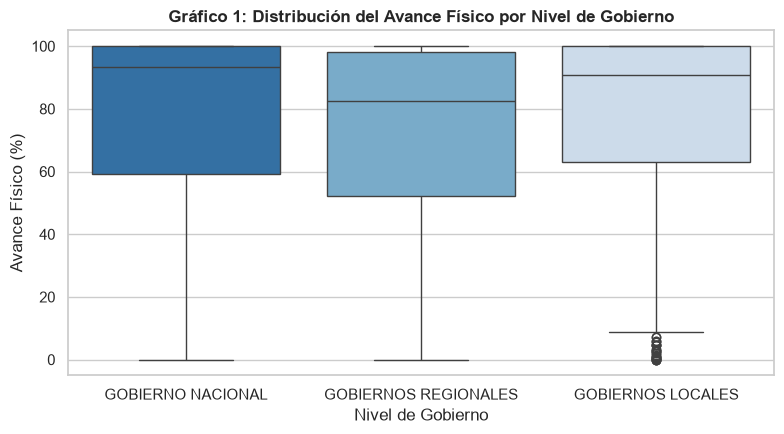

In [5]:
# 1. Filtramos los proyectos en ejecución activa con avance físico y gasto real
filtro = (
    (base_integrada["origen_cruce"] == "both") &
    (base_integrada["avance_fisico_pct"].notna()) &
    (base_integrada["costo_inversion"] > 0) &
    (base_integrada["gasto_total"] > 0)
)
df_eda = base_integrada[filtro].copy()

# 2. Calculamos las variables para los gráficos
df_eda["pct_ejecucion"] = (df_eda["gasto_total"] / df_eda["costo_inversion"]) * 100
df_eda["brecha"] = df_eda["pct_ejecucion"] - df_eda["avance_fisico_pct"]
df_eda["alerta"] = (df_eda["brecha"] > 15.0).astype(int)

order_gob = ["GOBIERNO NACIONAL", "GOBIERNOS REGIONALES", "GOBIERNOS LOCALES"]
print(f"Proyectos en ejecución activa para el EDA: {len(df_eda):,}")

# Gráfico 1: Boxplot de Avance Físico por Gobierno
plt.figure(figsize=(8, 4.5))
sns.boxplot(data=df_eda, x="nivel_gobierno", y="avance_fisico_pct", order=order_gob, palette="Blues_r")
plt.title("Gráfico 1: Distribución del Avance Físico por Nivel de Gobierno", fontweight="bold")
plt.xlabel("Nivel de Gobierno")
plt.ylabel("Avance Físico (%)")
plt.show()


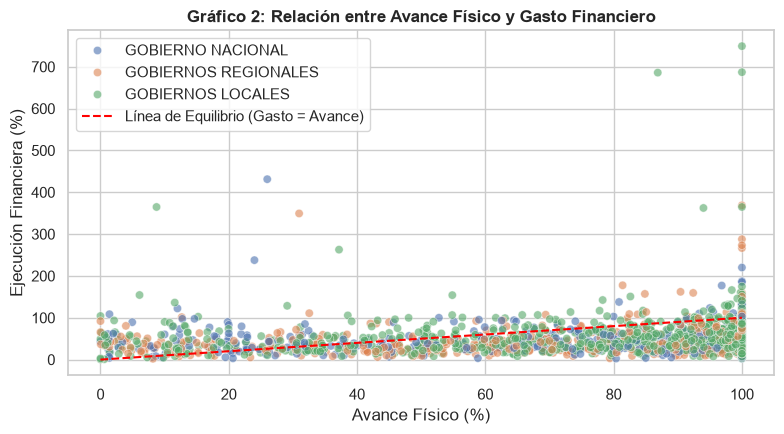

In [12]:
# Gráfico 2: Dispersión Gasto Financiero vs. Avance Físico
plt.figure(figsize=(8, 4.5))
sns.scatterplot(data=df_eda, x="avance_fisico_pct", y="pct_ejecucion", hue="nivel_gobierno", alpha=0.6)
plt.plot([0, 100], [0, 100], color="red", linestyle="--", label="Línea de Equilibrio (Gasto = Avance)")
plt.title("Gráfico 2: Relación entre Avance Físico y Gasto Financiero", fontweight="bold")
plt.xlabel("Avance Físico (%)")
plt.ylabel("Ejecución Financiera (%)")
plt.legend()
plt.show()


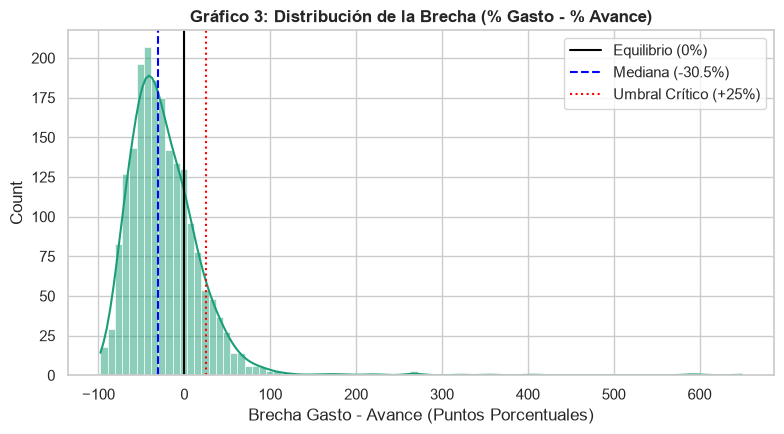

In [6]:
# Gráfico 3: Histograma de la Brecha (Gasto - Avance)
plt.figure(figsize=(8, 4.5))
sns.histplot(data=df_eda, x="brecha", kde=True, color="#1b9e77")
plt.axvline(0, color="black", linestyle="-", label="Equilibrio (0%)")
plt.axvline(df_eda["brecha"].median(), color="blue", linestyle="--", label=f"Mediana ({df_eda['brecha'].median():.1f}%)")
plt.axvline(25, color="red", linestyle=":", label="Umbral Crítico (+25%)")
plt.title("Gráfico 3: Distribución de la Brecha (% Gasto - % Avance)", fontweight="bold")
plt.xlabel("Brecha Gasto - Avance (Puntos Porcentuales)")
plt.legend()
plt.show()


C:\Users\Fernando\AppData\Local\Temp\ipykernel_18440\3091039193.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pct_alerta.index, y=pct_alerta.values, palette="Blues_r")


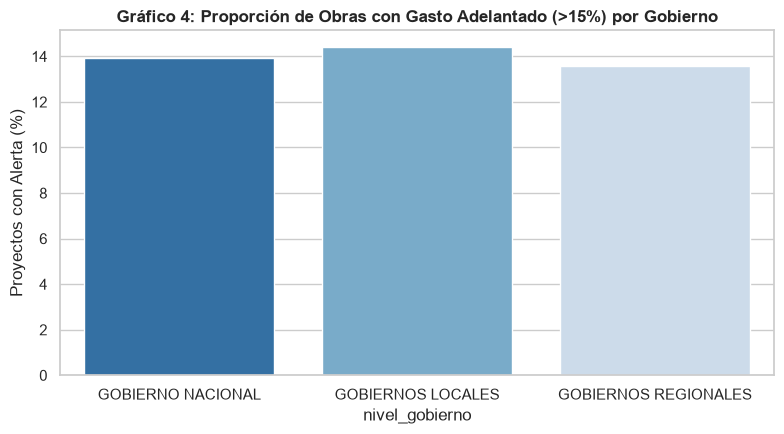

In [13]:
# Gráfico 4: Proporción de Obras con Alerta de Gasto Adelantado (>15%)
plt.figure(figsize=(8, 4.5))
pct_alerta = df_eda.groupby("nivel_gobierno")["alerta"].mean() * 100
sns.barplot(x=pct_alerta.index, y=pct_alerta.values, palette="Blues_r")
plt.title("Gráfico 4: Proporción de Obras con Gasto Adelantado (>15%) por Gobierno", fontweight="bold")
plt.ylabel("Proyectos con Alerta (%)")
plt.show()


---
# <font color=darkgreen>7. Transformaciones Aplicadas y Construcción de la Matriz Analítica</font>

Aplicamos una secuencia rigurosa de ingeniería de características para preparar los datos hacia la fase de modelado analítico:


## <font color=darkgreen>7.1. Creación de variables derivadas de negocio</font>

Construimos nuevas características respetando estrictamente la unidad de análisis (1 fila = 1 Proyecto CUI):
- `pct_ejecucion_financiera`: `(gasto_total / costo_inversion) * 100`
- `brecha_gasto_avance`: diferencia entre el porcentaje de gasto financiero y el avance físico real.
- `flag_gasto_adelantado`: variable indicadora binaria (1 si brecha > 15 puntos, 0 en caso contrario).
- `tiempo_maduracion_anios`: tiempo de vida del proyecto en el banco de inversiones en años.
- `gasto_anual_promedio`: velocidad media de ejecución financiera anual.


In [14]:
base_final = df_eda.copy()

# 1. Porcentaje de ejecución financiera y brecha
base_final["pct_ejecucion_financiera"] = (base_final["gasto_total"] / base_final["costo_inversion"]) * 100
base_final["brecha_gasto_avance"] = base_final["pct_ejecucion_financiera"] - base_final["avance_fisico_pct"]

# 2. Indicador binario: ¿El proyecto tuvo gasto adelantado significativo? (0 = No, 1 = Sí)
base_final["flag_gasto_adelantado"] = (base_final["brecha_gasto_avance"] > 15.0).astype(int)

# 3. Tiempo de maduración del proyecto y gasto anual promedio
base_final["tiempo_maduracion_anios"] = base_final["anio_fin"] - base_final["anio_inicio"] + 1
base_final["gasto_anual_promedio"] = base_final["gasto_total"] / base_final["tiempo_maduracion_anios"]

display(base_final[["codigo_proyecto", "pct_ejecucion_financiera", "avance_fisico_pct", "brecha_gasto_avance", "flag_gasto_adelantado", "tiempo_maduracion_anios", "gasto_anual_promedio"]].head(3))


,codigo_proyecto,pct_ejecucion_financiera,avance_fisico_pct,brecha_gasto_avance,flag_gasto_adelantado,tiempo_maduracion_anios,gasto_anual_promedio
2,2002060,70.288247,100.0,-29.711753,0,22,8.419162e+06
4,2002210,64.647724,100.0,-35.352276,0,22,7.908024e+06
5,2002604,36.607377,100.0,-63.392623,0,22,3.157345e+06


## <font color=darkgreen>7.2. Discretización de variables cuantitativas</font>

Discretizamos con `pd.cut()` aplicando umbrales presupuestales definidos por normativa y mapeo ordinal explícito, evaluando adicionalmente cuantiles con `pd.qcut()`.


In [15]:
# 1. Intervalos de negocio definidos con pd.cut()
base_final["tamano_inversion"] = pd.cut(
    base_final["costo_inversion"],
    bins=[0, 1.5e6, 10e6, 50e6, float("inf")],
    labels=["Pequeño", "Mediano", "Grande", "Megaproyecto"]
)

# Codificación ordinal explícita para preservar la jerarquía de escala
orden_tamano = {"Pequeño": 0, "Mediano": 1, "Grande": 2, "Megaproyecto": 3}
base_final["tamano_inversion_ord"] = base_final["tamano_inversion"].map(orden_tamano).astype(int)

# 2. Segmentación comparativa por cuantiles con pd.qcut()
base_final["costo_grupo"] = pd.qcut(
    base_final["costo_inversion"],
    q=3,
    labels=["Bajo", "Medio", "Alto"]
)

display(base_final[["codigo_proyecto", "costo_inversion", "tamano_inversion", "tamano_inversion_ord", "costo_grupo"]].head(3))



,codigo_proyecto,costo_inversion,tamano_inversion,tamano_inversion_ord,costo_grupo
2,2002060,2.635171e+08,Megaproyecto,3,Alto
4,2002210,2.691147e+08,Megaproyecto,3,Alto
5,2002604,1.897475e+08,Megaproyecto,3,Alto


## <font color=darkgreen>7.3. Codificación de variables nominales (One-Hot Encoding)</font>

Aplicamos One-Hot Encoding sobre `nivel_gobierno` empleando `drop_first=True` para evitar colinealidad exacta en modelos que requieran inversión matricial.


In [16]:
base_final_transformada = pd.get_dummies(
    base_final,
    columns=["nivel_gobierno"],
    prefix="gob",
    drop_first=True,
    dtype=int
)

columnas_gobierno = [
    columna
    for columna in base_final_transformada.columns
    if columna.startswith("gob_")
]

print("Columnas One-Hot generadas:")
print(columnas_gobierno)
display(base_final_transformada[["codigo_proyecto"] + columnas_gobierno].head(3))


Columnas One-Hot generadas:
['gob_GOBIERNOS LOCALES', 'gob_GOBIERNOS REGIONALES']


,codigo_proyecto,gob_GOBIERNOS LOCALES,gob_GOBIERNOS REGIONALES
2,2002060,0,0
4,2002210,0,0
5,2002604,0,1


## <font color=darkgreen>7.4. Escalamiento de variables numéricas continuas</font>

Revisamos las variables numéricas cuantitativas continuas antes de la normalización.  
> **Criterio metodológico:** **No se escalan** variables binarias (`flag_gasto_adelantado`), ni columnas One-Hot (`gob_`), ni variables ordinales (`tamano_inversion_ord`), debido a que su representación numérica ya posee significado estructural propio. El escalamiento se reserva exclusivamente a las **variables cuantitativas continuas** de magnitud monetaria, temporal y porcentual.


In [17]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Seleccionamos únicamente las variables cuantitativas continuas a escalar
variables_escalar = [
    "pct_ejecucion_financiera",
    "avance_fisico_pct",
    "brecha_gasto_avance",
    "costo_inversion",
    "gasto_total",
    "tiempo_maduracion_anios",
    "gasto_anual_promedio",
    "n_registros_presupuesto",
    "n_contratos"
]

display(base_final_transformada[variables_escalar].describe().T[["min", "max", "mean", "std"]])


,min,max,mean,std
pct_ejecucion_financiera,0.580709,7.492497e+02,5.264197e+01,4.395292e+01
avance_fisico_pct,0.000000,1.000000e+02,7.556357e+01,2.954094e+01
brecha_gasto_avance,-97.668806,6.492497e+02,-2.292160e+01,4.883172e+01
costo_inversion,15362.500000,1.207545e+10,4.198387e+07,2.924782e+08
gasto_total,14560.600000,1.837811e+09,1.309473e+07,5.472380e+07
tiempo_maduracion_anios,1.000000,2.200000e+01,1.094237e+01,3.374862e+00
gasto_anual_promedio,2080.085714,1.413701e+08,1.056449e+06,4.059342e+06
n_registros_presupuesto,1.000000,8.700000e+01,1.398079e+01,7.752405e+00
n_contratos,1.000000,4.590000e+03,1.692154e+02,2.700891e+02


---
# <font color=navy>7.5. Estructura y Representaciones de la Matriz Analítica Final</font>
### *Definición de dimensionalidad y matrices alternativas para modelado analítico*

- **Unidad de análisis:** 1,978 Proyectos de Inversión Pública (CUI) en ejecución activa con avance físico reportado en `Proceso_Seleccion` y gasto devengado en `Seguimiento_PI`.
- **Atributos de la matriz (13 variables):**
  - **9 Cuantitativas Continuas:** `pct_ejecucion_financiera`, `avance_fisico_pct`, `brecha_gasto_avance`, `costo_inversion`, `gasto_total`, `tiempo_maduracion_anios`, `gasto_anual_promedio`, `n_registros_presupuesto`, `n_contratos`.
  - **1 Binaria:** `flag_gasto_adelantado`.
  - **1 Ordinal:** `tamano_inversion_ord` (valores discretos 0 a 3).
  - **2 Dummies One-Hot:** `gob_GOBIERNOS LOCALES`, `gob_GOBIERNOS REGIONALES`.
- **Decisiones de exclusión:**
  - El identificador `codigo_proyecto` se conservó por separado en `id_proyecto` para asegurar trazabilidad analítica sin sesgar los modelos.
  - Se excluyeron proyectos sin costo o sin avance reportado para evitar imputaciones ficticias.
- **Tres representaciones analíticas comparadas:** Matriz original sin escalar, versión normalizada con **Min-Max** $[0, 1]$ (óptima para algoritmos basados en distancias euclidianas) y versión estandarizada con **Z-Score** ($\mu=0, \sigma=1$).


In [18]:
# 1. Conservamos id_proyecto por separado para trazabilidad analítica
id_proyecto = base_final_transformada["codigo_proyecto"].copy()

# 2. Definimos las columnas finales de la matriz analítica
columnas_finales = [
    "pct_ejecucion_financiera",
    "avance_fisico_pct",
    "brecha_gasto_avance",
    "costo_inversion",
    "gasto_total",
    "tiempo_maduracion_anios",
    "gasto_anual_promedio",
    "n_registros_presupuesto",
    "n_contratos",
    "flag_gasto_adelantado",
    "tamano_inversion_ord"
] + columnas_gobierno

matriz_analitica_final = base_final_transformada[columnas_finales].copy()

# 3. Dos representaciones escaladas alternativas para diferentes algoritmos
minmax = MinMaxScaler()
estandarizador = StandardScaler()

matriz_final_minmax = matriz_analitica_final.copy()
matriz_final_zscore = matriz_analitica_final.copy()

# Aplicamos Min-Max únicamente a las variables cuantitativas continuas
matriz_final_minmax[variables_escalar] = minmax.fit_transform(matriz_final_minmax[variables_escalar])

# Aplicamos Z-score únicamente a esas mismas variables
matriz_final_zscore[variables_escalar] = estandarizador.fit_transform(matriz_final_zscore[variables_escalar])

# Comparamos las tres representaciones:
print("1. Matriz Analítica original sin escalar:")
display(matriz_analitica_final.head(3))

print("\n2. Matriz con normalización Min-Max:")
display(matriz_final_minmax.head(3))

print("\n3. Matriz con estandarización Z-Score:")
display(matriz_final_zscore.head(3))


1. Matriz Analítica original sin escalar:


,pct_ejecucion_financiera,avance_fisico_pct,brecha_gasto_avance,costo_inversion,gasto_total,tiempo_maduracion_anios,gasto_anual_promedio,n_registros_presupuesto,n_contratos,flag_gasto_adelantado,tamano_inversion_ord,gob_GOBIERNOS LOCALES,gob_GOBIERNOS REGIONALES
2,70.288247,100.0,-29.711753,2.635171e+08,1.852216e+08,22,8.419162e+06,39,63.0,0,3,0,0
4,64.647724,100.0,-35.352276,2.691147e+08,1.739765e+08,22,7.908024e+06,25,27.0,0,3,0,0
5,36.607377,100.0,-63.392623,1.897475e+08,6.946158e+07,22,3.157345e+06,27,38.0,0,3,0,1



2. Matriz con normalización Min-Max:


,pct_ejecucion_financiera,avance_fisico_pct,brecha_gasto_avance,costo_inversion,gasto_total,tiempo_maduracion_anios,gasto_anual_promedio,n_registros_presupuesto,n_contratos,flag_gasto_adelantado,tamano_inversion_ord,gob_GOBIERNOS LOCALES,gob_GOBIERNOS REGIONALES
2,0.093109,1.0,0.090983,0.021821,0.100777,1.0,0.059540,0.441860,0.013511,0,3,0,0
4,0.085575,1.0,0.083431,0.022285,0.094658,1.0,0.055925,0.279070,0.005666,0,3,0,0
5,0.048121,1.0,0.045890,0.015712,0.037788,1.0,0.022320,0.302326,0.008063,0,3,0,1



3. Matriz con estandarización Z-Score:


,pct_ejecucion_financiera,avance_fisico_pct,brecha_gasto_avance,costo_inversion,gasto_total,tiempo_maduracion_anios,gasto_anual_promedio,n_registros_presupuesto,n_contratos,flag_gasto_adelantado,tamano_inversion_ord,gob_GOBIERNOS LOCALES,gob_GOBIERNOS REGIONALES
2,0.401583,0.827415,-0.139087,0.757627,3.146170,3.277298,1.814229,3.228100,-0.393360,0,3,0,0
4,0.273219,0.827415,-0.254626,0.776770,2.940631,3.277298,1.688280,1.421752,-0.526683,0,3,0,0
5,-0.364905,0.827415,-0.828995,0.505340,1.030285,3.277298,0.517677,1.679802,-0.485945,0,3,0,1


## <font color=darkgreen>7.6. Verificación de Integridad de la Matriz Analítica</font>

Comprobamos dimensiones finales, ausencia absoluta de valores nulos y consistencia en los tipos de datos de la matriz.


In [19]:
print("Filas de la base consolidada:", base_final_transformada.shape[0])
print("Filas de la matriz analítica final:", matriz_analitica_final.shape[0])

print("\nFaltantes en la matriz final:")
print(matriz_analitica_final.isna().sum())

print("\nTipos de datos finales:")
print(matriz_analitica_final.dtypes)

print("\nDimensiones finales:", matriz_analitica_final.shape)


Filas de la base consolidada: 1978
Filas de la matriz analítica final: 1978

Faltantes en la matriz final:
pct_ejecucion_financiera    0
avance_fisico_pct           0
brecha_gasto_avance         0
costo_inversion             0
gasto_total                 0
tiempo_maduracion_anios     0
gasto_anual_promedio        0
n_registros_presupuesto     0
n_contratos                 0
flag_gasto_adelantado       0
tamano_inversion_ord        0
gob_GOBIERNOS LOCALES       0
gob_GOBIERNOS REGIONALES    0
dtype: int64

Tipos de datos finales:
pct_ejecucion_financiera    float64
avance_fisico_pct           float64
brecha_gasto_avance         float64
costo_inversion             float64
gasto_total                 float64
tiempo_maduracion_anios       int64
gasto_anual_promedio        float64
n_registros_presupuesto       int64
n_contratos                 float64
flag_gasto_adelantado         int64
tamano_inversion_ord          int64
gob_GOBIERNOS LOCALES         int64
gob_GOBIERNOS REGIONALES      int

---
# <font color=navy>8. Siguiente Fase: Modelado Analítico No Supervisado</font>
### *Plan de experimentación con algoritmos de clustering, detección de anomalías y validación externa*

1. **Modelado en la Siguiente Fase (Hito 3):**
   - **Clustering No Supervisado (K-Means y DBSCAN):** Segmentar tipologías naturales de proyectos según su tamaño, velocidad de gasto y nivel de cumplimiento físico.
   - **Detección de Anomalías (Isolation Forest y Distancia de Mahalanobis):** Identificar proyectos atípicos con desbalances severos de gasto respecto a avance físico para focalizar acciones de fiscalización.
2. **Validación Externa Cruzada:**
   - Contrastar los proyectos etiquetados como anómalos o de alto riesgo frente a la base oficial de obras paralizadas y procesos en arbitraje reportados en el portal **INFOBRAS** de la Contraloría General de la República.
